In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

import numpy as np
import torch
import torch.distributions as dists
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp
import os
import xarray

from equayes import Equayes, PROJECT_ROOT, Constraint
from equayes.core.pyro_backend import utils as pyro_utils

In [19]:
import matplotlib as mpl

font_size_small = 12
font_size_big = 14

mpl.rcParams["legend.fontsize"] = font_size_big  # legend labels
mpl.rcParams["axes.labelsize"] = font_size_big  # x/y axis labels
mpl.rcParams["xtick.labelsize"] = font_size_small  # x tick labels
mpl.rcParams["ytick.labelsize"] = font_size_small

In [20]:
"""
A Cantilever is a beam, that is mounted on one side and free anywhere else.
Its volume and material properties define its natural frequencies analytically.
This function models this frequency.
You can also consider it as parameterized black-box model that describes our physical knowledge for the rest of the tutorial.
"""


def cantilever_natural_frequency(
    length: torch.Tensor,  # L [m]
    width: torch.Tensor,  # b [m]
    height: torch.Tensor,  # h [m]
    density: torch.Tensor,  # rho [kg/m^3]
    youngs_modulus: torch.Tensor,  # E [Pa]
    mode: int = 1,  # vibration mode number
):
    beta = {1: 1.875, 2: 4.694, 3: 7.855, 4: 10.996}[mode]

    A = width * height
    I = (width * height**3) / 12

    frequency = (beta**2 / (2 * torch.pi * length**2)) * torch.sqrt((youngs_modulus * I) / (density * A))

    return frequency

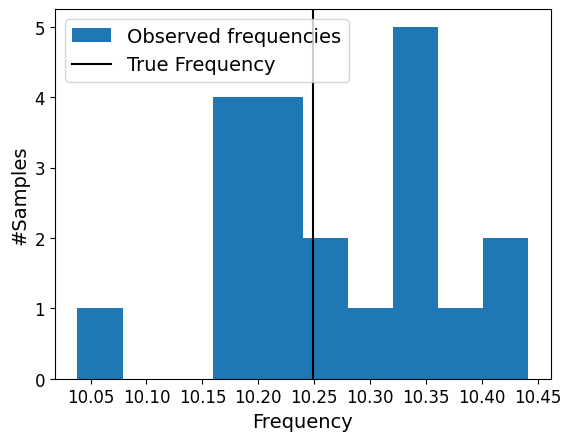

In [21]:
"""
Define an instance of a Cantilever.
We assume that we have access to a limited number of noisy measurements of the frequency of the lever.
"""

length_true = torch.tensor(0.9)  # m
width_true = torch.tensor(0.01)  # m
height_true = torch.tensor(0.01)  # m
density_true = torch.tensor(7950.0)  # kg/m^3
youngs_modulus_true = torch.tensor(210e9)  # Pa
measurement_noise_true = 0.1

n_observations = 20
# fix the seed for repeatability
torch.manual_seed(42)

true_natural_frequency = cantilever_natural_frequency(length_true, width_true, height_true, density_true, youngs_modulus_true)
frequencies = dists.Normal(
    true_natural_frequency,
    measurement_noise_true,
).sample((n_observations,))

plt.hist(frequencies, label="Observed frequencies")
plt.axvline(true_natural_frequency, color="black", zorder=5, label="True Frequency")
plt.xlabel("Frequency")
plt.ylabel("#Samples")
plt.legend()

In [22]:
"""Define the cantilever governing equations in sympy - this is the input for Equayes"""

length, width, height, density, youngs_modulus, beta = sp.symbols(
    ["length", "width", "height", "density", "youngs_modulus", "beta"]
)
A = sp.UnevaluatedExpr(
    width * height
)  # sympy automatically simplifies all expressions. Use UnevaluatedExpr to keep the sympy string as close to the definition as possible
I = sp.UnevaluatedExpr((width * height**3) / 12)

frequency_eq = sp.UnevaluatedExpr((beta**2 / (2 * sp.pi * length**2)) * sp.sqrt((youngs_modulus * I) / (density * A)))
print(frequency_eq)  # note: independent of the width, as it (correctly) cancels in the formula

beta**2*sqrt(youngs_modulus*(height**3*width/12)*(height*width)**(-1)/density)/(2*pi*length**2)


In [23]:
# setup Equayes
# Note: Equayes replaces all floating point constants in an expression with random variables.
#   So, we could substitute the density with an initial guess to convert it to a random variable.
#   However, if we substitute the density with a default floating point value, sympy will perform all mathematical operations with other constants, so this would make the result uninterpretable.
#   Therefore, Equayes offers the field `latent_variables`, such that we can define a symbol (here density) that will be treated as a random variable.

equayes = Equayes(
    expr=frequency_eq,
    input_symbols=[length, width, height, youngs_modulus, beta],
    latent_variables=[density],
    latent_variable_constraints={
        density: Constraint.POSITIVE
    },  # density must be positive. experiment what happens, if you don't set the constraint.
    output_dim=1,
    # explore different inference methods by changing parameters: inference_method_name, kernel_name.
    jit_compile=True,  # speed up computations
)

In [24]:
# create the fixed X_train data for each observation. required shape: (N_observations, M_input_features)
# we assume perfect knowledge of X_train, hence, we repeat the true values for each observation.
beta_true = torch.tensor(1.875)
X_train = (
    torch.stack((length_true, width_true, height_true, youngs_modulus_true, beta_true)).view(1, -1).expand(n_observations, -1)
)
print(f"Shape X_train: {X_train.shape}")
equayes.fit(X_train, frequencies.view(-1, 1))

Shape X_train: torch.Size([20, 5])


Warmup:   0%|          | 0/3500 [00:00, ?it/s]Sample: 100%|██████████| 3500/3500 [00:52, 66.38it/s, step size=6.98e-01, acc. prob=0.928]


# Evaluation

In [25]:
# define results folder
results_base_path = f"{PROJECT_ROOT}/output/cantilever/"
os.makedirs(results_base_path, exist_ok=True)

In [26]:
# First, evaluate, if inference was successful.
# Using MCMC: r_hat should be within [0.98, 1.01]
# Using VI: The loss should converge to a flat line
inference_diagnostics = equayes.inference_diagnostics()
if "loss" in inference_diagnostics.keys():
    losses = inference_diagnostics["loss"]
    plt.plot(np.linspace(0, len(losses), len(losses)), losses)
    plt.xlabel("VI iteration")
    plt.ylabel("Loss")


                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
                    epsilon[0]      0.11      0.02      0.10      0.08      0.13   1071.47      1.00
theta_density_unconstrained[0]      8.98      0.00      8.98      8.97      8.98   1376.64      1.00

Number of divergences: 0


In [29]:
# save the posterior

inference_dt = equayes.get_posterior()
if type(inference_dt) is not xarray.DataTree:
    inference_dt = pyro_utils.guide_to_inference_data(equayes._pyro_model, equayes._guide, X_train, num_samples=3000)


inference_dt.to_netcdf(
    f"{results_base_path}/posterior_{equayes.inference_method_name}_{equayes.kernel_name}.ntcdf"
)  # for memory efficient, binary format storage

In [30]:
inference_dt = az.from_netcdf(f"{results_base_path}/posterior_{equayes.inference_method_name}_{equayes.kernel_name}.ntcdf")
equayes.load_posterior_arviz(inference_dt)

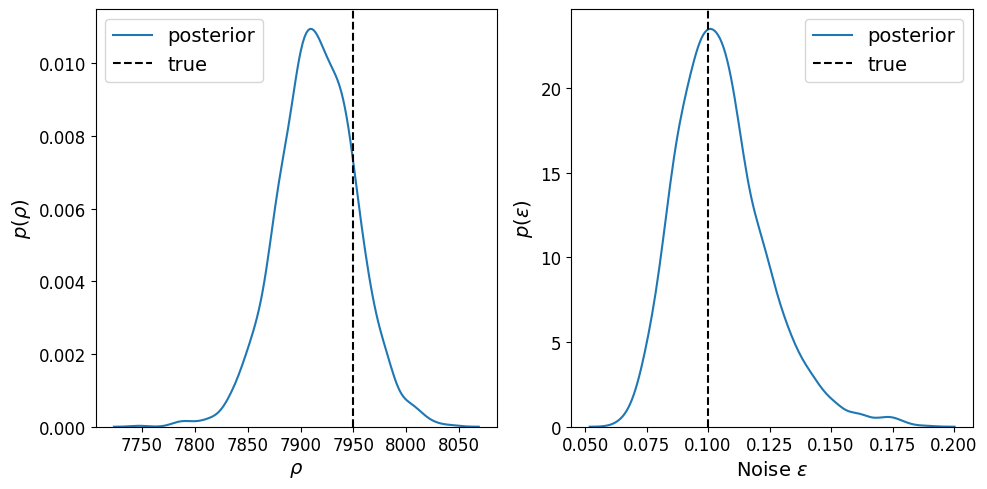

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.kdeplot(np.exp(np.ravel(inference_dt["posterior"]["theta_density_unconstrained"])), ax=axs[0], label="posterior")
axs[0].axvline(density_true, label="true", linestyle="--", color="black")
axs[0].set_xlabel(r"$\rho$")
axs[0].set_ylabel(r"$p(\rho)$")
axs[0].legend()

sns.kdeplot(np.ravel(inference_dt["posterior"]["epsilon"]), ax=axs[1], label="posterior")
axs[1].axvline(measurement_noise_true, label="true", linestyle="--", color="black")
axs[1].set_xlabel(r"Noise $\epsilon$")
axs[1].set_ylabel(r"$p(\epsilon)$")
axs[1].legend()

plt.tight_layout()
plt.savefig(f"{results_base_path}posterior_{equayes.inference_method_name}_{equayes.kernel_name}.png")

In [32]:
num_predictive_samples = 1000

prior_predictive_samples = equayes.predict(
    torch.stack((length_true, width_true, height_true, youngs_modulus_true, beta_true)).view(1, -1),
    sample_prior=True,
    parallel=True,
    n_predictive_samples=num_predictive_samples,
)
post_predictive_samples = equayes.predict(
    torch.stack((length_true, width_true, height_true, youngs_modulus_true, beta_true)).view(1, -1),
    sample_prior=False,
    parallel=True,
    n_predictive_samples=num_predictive_samples,
)

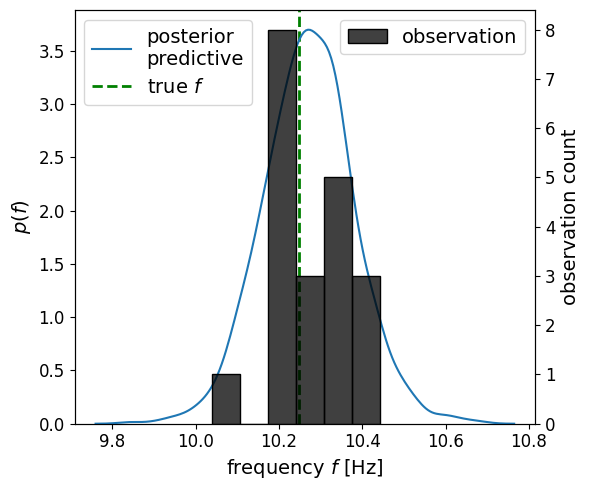

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.kdeplot(np.ravel(post_predictive_samples["obs"]), label="posterior\npredictive", zorder=3)
ax2 = ax.twinx()
sns.histplot(frequencies, label="observation", color="black", zorder=1, ax=ax2)
ax.axvline(true_natural_frequency, label="true $f$", color="green", linestyle="--", linewidth=2)
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
ax.set_xlabel(r"frequency $f$ [Hz]")
ax2.set_ylabel("observation count")
ax.set_ylabel(r"$p(f)$")
plt.tight_layout()
plt.savefig(f"{results_base_path}posterior_predictive_{equayes.inference_method_name}_{equayes.kernel_name}.png")